In [1]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline
import torch.nn.functional as F

In [2]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# building the vocabulary of the characters and mapping them to /from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next token
X, Y = [], []
for w in words:
    
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(f"{''.join(itos[i] for i in context)} ----> {itos[ix]}")
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [67]:
g = torch.Generator().manual_seed(2147483647) # for reproducability
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6,100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn((27), generator=g)
parameters = [C,W1,b1,W2,b2]

In [68]:
sum(p.nelement() for p in parameters) # total number of parameters

3481

In [69]:
for p in parameters:
    p.requires_grad = True

In [70]:
lre = torch.linspace(-3,1, 1000)
lrs = 10**lre

In [71]:
lri = []
lossi = []

for i in range(1000):

    # mini batches ix
    ix = torch.randint(0,X.shape[0],(32,))

    # forward pass
    emb = C[X[ix]] # still 32,3,2
    h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
    logits = h @ W2 + b2 # (32,27)
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())
    

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    lri.append(lre[i])
    lossi.append(loss.item())

#print(loss.item())

17.717771530151367
21.133075714111328
19.50519371032715
20.794254302978516
19.173330307006836
21.31667137145996
19.11476707458496
19.91796112060547
21.476037979125977
19.296142578125
17.362274169921875
20.54375648498535
16.7148380279541
19.17953109741211
18.54816246032715
21.775930404663086
18.20252227783203
18.189062118530273
18.976530075073242
19.197322845458984
19.866971969604492
19.248046875
16.963560104370117
18.240751266479492
19.907461166381836
17.837371826171875
17.471860885620117
18.434432983398438
17.36394500732422
18.75687026977539
17.024221420288086
20.07846450805664
16.167882919311523
20.01104736328125
21.39982795715332
18.255685806274414
17.489763259887695
20.3267879486084
18.628122329711914
20.841272354125977
16.817644119262695
17.56528663635254
14.483981132507324
17.881242752075195
15.181835174560547
18.880077362060547
19.752117156982422
19.038522720336914
17.236913681030273
19.12040901184082
18.48474884033203
16.323823928833008
17.68844985961914
20.04841423034668
15.84

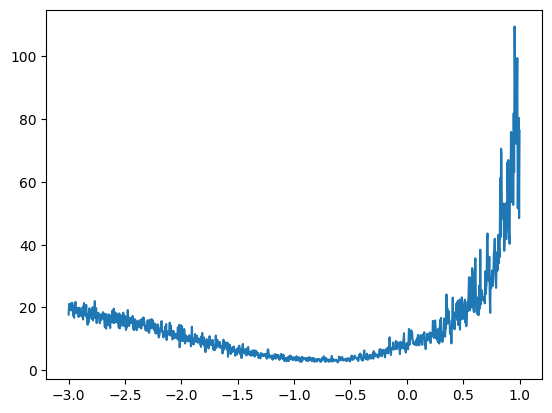

In [72]:
plt.plot(lri,lossi)

In [73]:
emb = C[X[ix]] # still 32,3,2
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits, Y[ix])
loss

tensor(45.5270, grad_fn=<NllLossBackward0>)